## This is a sample pandas project that exemplifies how to proceed data wrangling, specifically for data science and machine learning purposes, using Python, Pandas, NumPy, Matplotlib, Seaborn and xlrd

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# xlrd dependence (although already installed) is not needed at this project, as the spreadsheets are already in the 
# modern xlsx format. openpyxl is another dependence (also already installed) used instead.

In [2]:
wdi_data_df = pd.read_excel('(2.2) WDI World Bank.xlsx', na_values='..')
group_data_df = pd.read_excel('(2.3) WDI Income Group.xlsx')
countries_df = pd.read_excel('(2.4) WDI Country.xlsx')

# wdi_data_df is the main df (from the main xlsx spreadsheet) to whom the other dfs will be added to
# the main df imports the spreadsheet data setting already the ".." values as NaN, which is the expected value at 
# python for null values. It is done by setting the na_values param with the ".." arg value

In [3]:
wdi_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 383577 entries, 0 to 383576
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Country Name   383574 non-null  str    
 1   Country Code   383572 non-null  str    
 2   Series Name    383572 non-null  str    
 3   Series Code    383572 non-null  str    
 4   2021 [YR2021]  108687 non-null  float64
 5   Topic          383572 non-null  str    
dtypes: float64(1), str(5)
memory usage: 17.6 MB


In [4]:
# showing unique data from some variable columns (understand what the columns or variables are about)

In [5]:
wdi_data_df['Country Name'].unique()

<StringArray>
[                                     'Afghanistan',
                                          'Albania',
                                          'Algeria',
                                   'American Samoa',
                                          'Andorra',
                                           'Angola',
                              'Antigua and Barbuda',
                                        'Argentina',
                                          'Armenia',
                                            'Aruba',
 ...
                                       'South Asia',
                          'South Asia (IDA & IBRD)',
                               'Sub-Saharan Africa',
       'Sub-Saharan Africa (excluding high income)',
        'Sub-Saharan Africa (IDA & IBRD countries)',
                              'Upper middle income',
                                            'World',
                                                nan,
 'Data from database: World

In [6]:
wdi_data_df['Series Name'].unique()

<StringArray>
[                                                         'Access to clean fuels and technologies for cooking (% of population)',
                                             'Access to clean fuels and technologies for cooking, rural (% of rural population)',
                                             'Access to clean fuels and technologies for cooking, urban (% of urban population)',
                                                                                       'Access to electricity (% of population)',
                                                                          'Access to electricity, rural (% of rural population)',
                                                                          'Access to electricity, urban (% of urban population)',
               'Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)',
       'Account ownership at a financial institution or with a mobile-money-

In [7]:
wdi_data_df['Topic'].unique()

<StringArray>
[                                                              'Environment: Energy production & use',
                                                                           'Financial Sector: Access',
                                                             'Social Protection & Labor: Performance',
                                                                           'Education: Participation',
                               'Economic Policy & Debt: National accounts: Adjusted savings & income',
                                                                        'Health: Reproductive health',
                                                                               'Health: Risk factors',
                                                                       'Health: Population: Dynamics',
                                                                              'Environment: Land use',
                                                           

In [8]:
# renaming columns

wdi_data_df.rename(columns={'Country Name':'country',
                          'Country Code':'country_code',
                          'Series Name': 'series_name',
                          'Series Code': 'series_code',
                          '2021 [YR2021]': '2021_year',
                          'Topic': 'topic'}, inplace=True)
wdi_data_df

,country,country_code,series_name,series_code,2021_year,topic
0,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,Environment: Energy production & use
1,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,Environment: Energy production & use
2,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,Environment: Energy production & use
3,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,Environment: Energy production & use
4,Afghanistan,AFG,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,Environment: Energy production & use
...,...,...,...,...,...,...
383572,NaN,NaN,NaN,NaN,NaN,NaN
383573,NaN,NaN,NaN,NaN,NaN,NaN
383574,NaN,NaN,NaN,NaN,NaN,NaN
383575,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN


In [9]:
wdi_data_df['country'].tail(n=20)

383557                                               World
383558                                               World
383559                                               World
383560                                               World
383561                                               World
383562                                               World
383563                                               World
383564                                               World
383565                                               World
383566                                               World
383567                                               World
383568                                               World
383569                                               World
383570                                               World
383571                                               World
383572                                                 NaN
383573                                                 N

In [10]:
# deleting the last descriptive lines of the database that are not observations, but text descriptions of the data
# Actually we're selecting only the data that we'll use later to mount our own table, and disregard all the rest
# From this first main spreadsheet we're selecting here the first 383572 rows (from 0 to 383571), 383572 exclusive
my_wdi_data = wdi_data_df.iloc[0:383572,]
my_wdi_data["country"].tail(n=20)

383552    World
383553    World
383554    World
383555    World
383556    World
383557    World
383558    World
383559    World
383560    World
383561    World
383562    World
383563    World
383564    World
383565    World
383566    World
383567    World
383568    World
383569    World
383570    World
383571    World
Name: country, dtype: str

In [11]:
# selecting only the rows with topics related to Health - other topics do not matter for us

my_health_data = my_wdi_data[my_wdi_data['topic'].str.startswith('Health')]
my_health_data

,country,country_code,series_name,series_code,2021_year,topic
50,Afghanistan,AFG,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,NaN,Health: Reproductive health
54,Afghanistan,AFG,Adults (ages 15+) and children (ages 0-14) new...,SH.HIV.INCD.TL,1500.000000,Health: Risk factors
55,Afghanistan,AFG,Adults (ages 15-49) newly infected with HIV,SH.HIV.INCD,1300.000000,Health: Risk factors
56,Afghanistan,AFG,Age dependency ratio (% of working-age populat...,SP.POP.DPND,84.599257,Health: Population: Dynamics
57,Afghanistan,AFG,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,4.437872,Health: Population: Dynamics
...,...,...,...,...,...,...
383547,World,WLD,Use of insecticide-treated bed nets (% of unde...,SH.MLR.NETS.ZS,NaN,Health: Disease prevention
383549,World,WLD,Vitamin A supplementation coverage rate (% of ...,SN.ITK.VITA.ZS,NaN,Health: Nutrition
383556,World,WLD,Wanted fertility rate (births per woman),SP.DYN.WFRT,NaN,Health: Reproductive health
383570,World,WLD,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,53.800000,Health: Risk factors


In [12]:
# resetting the structure of the table to a better format: country and country_code become the index, series_name
# values become the column labels, and the values for each column are the 2021_year values for each of those column
# variables

my_health_data = pd.pivot(my_health_data, 
                       index=['country','country_code'], 
                       columns=['series_name'], 
                       values='2021_year')
my_health_data

,series_name,ARI treatment (% of children under 5 taken to a health provider),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),Antiretroviral therapy coverage for PMTCT (% of pregnant women living with HIV),"Birth rate, crude (per 1,000 people)",...,"Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)","Tuberculosis case detection rate (%, all forms)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Vitamin A supplementation coverage rate (% of children ages 6-59 months),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
country,country_code,,,,,,,,,,,,,,,,,,,,,
Afghanistan,AFG,NaN,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.000000,16.000000,NaN,...,NaN,66.0,NaN,NaN,NaN,NaN,NaN,NaN,29.100000,500.0
Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,81.190004,5.706194,74.565174,79.370724,89.943094,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.535130,NaN
Africa Western and Central,AFW,NaN,NaN,NaN,NaN,85.495451,5.337003,79.773361,77.519787,56.245001,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.923126,NaN
Albania,ALB,NaN,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.000000,NaN,NaN,...,NaN,56.0,NaN,NaN,NaN,NaN,NaN,NaN,26.600000,100.0
Algeria,DZA,NaN,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.000000,16.000000,NaN,...,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,46.900000,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,NaN,NaN,...,NaN,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
World,WLD,NaN,NaN,1500000.0,1200000.0,55.289803,14.821066,39.291501,75.000000,81.000000,NaN,...,NaN,61.0,NaN,NaN,NaN,NaN,NaN,NaN,53.800000,400000.0
"Yemen, Rep.",YEM,NaN,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.000000,NaN,NaN,...,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,34.400000,200.0


In [13]:
# setting the index again as an int Series with no label:
my_health_data.reset_index(inplace=True)
# removes redundant columns name label created by the pivot method:
my_health_data.columns.name = None
my_health_data

,country,country_code,ARI treatment (% of children under 5 taken to a health provider),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),...,"Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)","Tuberculosis case detection rate (%, all forms)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Vitamin A supplementation coverage rate (% of children ages 6-59 months),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Afghanistan,AFG,NaN,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.000000,...,NaN,66.0,NaN,NaN,NaN,NaN,NaN,NaN,29.100000,500.0
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,81.190004,5.706194,74.565174,79.370724,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.535130,NaN
2,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,85.495451,5.337003,79.773361,77.519787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.923126,NaN
3,Albania,ALB,NaN,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.000000,...,NaN,56.0,NaN,NaN,NaN,NaN,NaN,NaN,26.600000,100.0
4,Algeria,DZA,NaN,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.000000,...,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,46.900000,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,...,NaN,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,World,WLD,NaN,NaN,1500000.0,1200000.0,55.289803,14.821066,39.291501,75.000000,...,NaN,61.0,NaN,NaN,NaN,NaN,NaN,NaN,53.800000,400000.0
263,"Yemen, Rep.",YEM,NaN,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.000000,...,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,34.400000,200.0
264,Zambia,ZMB,NaN,NaN,38000.0,32000.0,81.822456,3.161765,78.660691,90.000000,...,NaN,84.0,NaN,NaN,NaN,NaN,NaN,NaN,61.900000,15000.0


In [14]:
# At the main df above, many of the observations are not from countries but from aggregations... for eliminating
# these, we'll merge the countries df with the main df, for later selecting only the observations that actually are 
# countries. PK will be country_code.

In [15]:
countries_df.rename(columns={'Country':'country_code'}, 
                    inplace=True)
countries_df

,country_code,Name
0,AFG,Islamic State of Afghanistan
1,ALB,Republic of Albania
2,DZA,People's Democratic Republic of Algeria
3,ASM,American Samoa
4,AND,Principality of Andorra
...,...,...
212,VIR,Virgin Islands of the United States
213,PSE,West Bank and Gaza
214,YEM,Republic of Yemen
215,ZMB,Republic of Zambia


In [16]:
# merging the countries df to the main df, with the actual names of each actual country. The variable country at the 
# original main df contains improper aggregated names of countries and observations that aren't a country. These will 
# be eliminated. When the merge finishes, as it's a left join merge, the Name variable at the right will be null for
# observations that are at the original main df but not at the countries df. These are the observations whose country
# value are not a country (is not contained at the countries df). These will be removed when we select only the not
# null rows, regarding the Name column, down below.

my_health_data = pd.merge(my_health_data, countries_df, 
                       how='left', 
                       on='country_code')
my_health_data

,country,country_code,ARI treatment (% of children under 5 taken to a health provider),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),...,"Tuberculosis case detection rate (%, all forms)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Vitamin A supplementation coverage rate (% of children ages 6-59 months),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV,Name
0,Afghanistan,AFG,NaN,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.000000,...,66.0,NaN,NaN,NaN,NaN,NaN,NaN,29.100000,500.0,Islamic State of Afghanistan
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,81.190004,5.706194,74.565174,79.370724,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.535130,NaN,NaN
2,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,85.495451,5.337003,79.773361,77.519787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.923126,NaN,NaN
3,Albania,ALB,NaN,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.000000,...,56.0,NaN,NaN,NaN,NaN,NaN,NaN,26.600000,100.0,Republic of Albania
4,Algeria,DZA,NaN,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.000000,...,79.0,NaN,NaN,NaN,NaN,NaN,NaN,46.900000,200.0,People's Democratic Republic of Algeria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,...,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West Bank and Gaza
262,World,WLD,NaN,NaN,1500000.0,1200000.0,55.289803,14.821066,39.291501,75.000000,...,61.0,NaN,NaN,NaN,NaN,NaN,NaN,53.800000,400000.0,NaN
263,"Yemen, Rep.",YEM,NaN,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.000000,...,59.0,NaN,NaN,NaN,NaN,NaN,NaN,34.400000,200.0,Republic of Yemen
264,Zambia,ZMB,NaN,NaN,38000.0,32000.0,81.822456,3.161765,78.660691,90.000000,...,84.0,NaN,NaN,NaN,NaN,NaN,NaN,61.900000,15000.0,Republic of Zambia


In [17]:
# eliminating null Name country observations (the observations whose country values were not contained at the 
# countries df, and, therefore, were not actual countries at all

my_health_data = my_health_data[~ my_health_data['Name'].isna()].reset_index(drop=True)
my_health_data

,country,country_code,ARI treatment (% of children under 5 taken to a health provider),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),...,"Tuberculosis case detection rate (%, all forms)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Vitamin A supplementation coverage rate (% of children ages 6-59 months),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV,Name
0,Afghanistan,AFG,NaN,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.0,...,66.0,NaN,NaN,NaN,NaN,NaN,NaN,29.1,500.0,Islamic State of Afghanistan
1,Albania,ALB,NaN,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.0,...,56.0,NaN,NaN,NaN,NaN,NaN,NaN,26.6,100.0,Republic of Albania
2,Algeria,DZA,NaN,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.0,...,79.0,NaN,NaN,NaN,NaN,NaN,NaN,46.9,200.0,People's Democratic Republic of Algeria
3,American Samoa,ASM,NaN,NaN,NaN,NaN,52.335690,10.425194,41.910496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa
4,Andorra,AND,NaN,NaN,NaN,NaN,38.140600,20.079704,18.060896,NaN,...,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Principality of Andorra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,NaN,64.603999,32.928574,31.675425,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Virgin Islands of the United States
213,West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,...,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West Bank and Gaza
214,"Yemen, Rep.",YEM,NaN,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.0,...,59.0,NaN,NaN,NaN,NaN,NaN,NaN,34.4,200.0,Republic of Yemen
215,Zambia,ZMB,NaN,NaN,38000.0,32000.0,81.822456,3.161765,78.660691,90.0,...,84.0,NaN,NaN,NaN,NaN,NaN,NaN,61.9,15000.0,Republic of Zambia


In [18]:
# we now may delete the Name column. The observations with improper country values are already removed.

my_health_data.drop(columns=['Name'], inplace=True)
my_health_data

,country,country_code,ARI treatment (% of children under 5 taken to a health provider),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),...,"Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)","Tuberculosis case detection rate (%, all forms)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Vitamin A supplementation coverage rate (% of children ages 6-59 months),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Afghanistan,AFG,NaN,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.0,...,NaN,66.0,NaN,NaN,NaN,NaN,NaN,NaN,29.1,500.0
1,Albania,ALB,NaN,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.0,...,NaN,56.0,NaN,NaN,NaN,NaN,NaN,NaN,26.6,100.0
2,Algeria,DZA,NaN,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.0,...,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,46.9,200.0
3,American Samoa,ASM,NaN,NaN,NaN,NaN,52.335690,10.425194,41.910496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,AND,NaN,NaN,NaN,NaN,38.140600,20.079704,18.060896,NaN,...,NaN,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,NaN,64.603999,32.928574,31.675425,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,...,NaN,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214,"Yemen, Rep.",YEM,NaN,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.0,...,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,34.4,200.0
215,Zambia,ZMB,NaN,NaN,38000.0,32000.0,81.822456,3.161765,78.660691,90.0,...,NaN,84.0,NaN,NaN,NaN,NaN,NaN,NaN,61.9,15000.0


In [19]:
# deleting all columns (variables) with NaN values at ALL their observations (we're not deleting the observations now, 
# but the variables (columns) themselves - axis=1). If the column has any observation with a value different from NaN,
# that column is kept.

my_health_data.dropna(axis=1, how='all', inplace=True)
my_health_data

,country,country_code,ARI treatment (% of children under 5 taken to a health provider),Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),Antiretroviral therapy coverage for PMTCT (% of pregnant women living with HIV),...,"Probability of dying among adolescents ages 15-19 years (per 1,000)","Probability of dying among children ages 5-9 years (per 1,000)","Probability of dying among youth ages 20-24 years (per 1,000)",Teenage mothers (% of women ages 15-19 who have had children or are currently pregnant),"Tuberculosis case detection rate (%, all forms)",Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Afghanistan,AFG,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.0,16.0,...,12.7,2.3,17.8,NaN,66.0,NaN,NaN,NaN,29.1,500.0
1,Albania,ALB,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.0,NaN,...,1.6,0.8,1.9,NaN,56.0,NaN,NaN,NaN,26.6,100.0
2,Algeria,DZA,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.0,16.0,...,2.4,1.4,3.0,NaN,79.0,NaN,NaN,NaN,46.9,200.0
3,American Samoa,ASM,NaN,NaN,NaN,52.335690,10.425194,41.910496,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,AND,NaN,NaN,NaN,38.140600,20.079704,18.060896,NaN,NaN,...,1.3,0.3,1.9,NaN,87.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,64.603999,32.928574,31.675425,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,West Bank and Gaza,PSE,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,NaN,...,3.4,1.7,4.2,NaN,80.0,NaN,NaN,NaN,NaN,NaN
214,"Yemen, Rep.",YEM,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.0,NaN,...,8.4,4.4,13.3,NaN,59.0,NaN,NaN,NaN,34.4,200.0
215,Zambia,ZMB,NaN,38000.0,32000.0,81.822456,3.161765,78.660691,90.0,97.0,...,8.6,6.5,11.9,NaN,84.0,NaN,NaN,NaN,61.9,15000.0


In [20]:
# now, we wish to add to the main df a single variable called Income Group, from the group df. The PK again is Code or
# country_code.

group_data_sub_df = group_data_df[['Code', 'Income Group']].copy()
group_data_sub_df

,Code,Income Group
0,AFG,Low income
1,ALB,Upper middle income
2,DZA,Lower middle income
3,ASM,Upper middle income
4,AND,High income
...,...,...
260,SSF,NaN
261,SSA,NaN
262,TSS,NaN
263,UMC,NaN


In [21]:
# changing the PK to the same PK name at the main df

group_data_sub_df.rename(columns={'Code':'country_code'}, 
                          inplace=True)
group_data_sub_df

,country_code,Income Group
0,AFG,Low income
1,ALB,Upper middle income
2,DZA,Lower middle income
3,ASM,Upper middle income
4,AND,High income
...,...,...
260,SSF,NaN
261,SSA,NaN
262,TSS,NaN
263,UMC,NaN


In [22]:
# performing the merge

my_health_data = pd.merge(my_health_data, group_data_sub_df, 
                       how='left', 
                       on='country_code')
my_health_data

,country,country_code,ARI treatment (% of children under 5 taken to a health provider),Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),Antiretroviral therapy coverage for PMTCT (% of pregnant women living with HIV),...,"Probability of dying among children ages 5-9 years (per 1,000)","Probability of dying among youth ages 20-24 years (per 1,000)",Teenage mothers (% of women ages 15-19 who have had children or are currently pregnant),"Tuberculosis case detection rate (%, all forms)",Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV,Income Group
0,Afghanistan,AFG,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.0,16.0,...,2.3,17.8,NaN,66.0,NaN,NaN,NaN,29.1,500.0,Low income
1,Albania,ALB,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.0,NaN,...,0.8,1.9,NaN,56.0,NaN,NaN,NaN,26.6,100.0,Upper middle income
2,Algeria,DZA,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.0,16.0,...,1.4,3.0,NaN,79.0,NaN,NaN,NaN,46.9,200.0,Lower middle income
3,American Samoa,ASM,NaN,NaN,NaN,52.335690,10.425194,41.910496,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Upper middle income
4,Andorra,AND,NaN,NaN,NaN,38.140600,20.079704,18.060896,NaN,NaN,...,0.3,1.9,NaN,87.0,NaN,NaN,NaN,NaN,NaN,High income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,64.603999,32.928574,31.675425,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High income
213,West Bank and Gaza,PSE,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,NaN,...,1.7,4.2,NaN,80.0,NaN,NaN,NaN,NaN,NaN,Lower middle income
214,"Yemen, Rep.",YEM,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.0,NaN,...,4.4,13.3,NaN,59.0,NaN,NaN,NaN,34.4,200.0,Low income
215,Zambia,ZMB,NaN,38000.0,32000.0,81.822456,3.161765,78.660691,90.0,97.0,...,6.5,11.9,NaN,84.0,NaN,NaN,NaN,61.9,15000.0,Low income


In [23]:
# reordering the columns

income_group_series = my_health_data.pop('Income Group')
income_group_series

0               Low income
1      Upper middle income
2      Lower middle income
3      Upper middle income
4              High income
              ...         
212            High income
213    Lower middle income
214             Low income
215             Low income
216    Lower middle income
Name: Income Group, Length: 217, dtype: str

In [24]:
# insert the poped series into column position 2 (as the 3rd column)

my_health_data.insert(2, 'Group', income_group_series)
my_health_data

,country,country_code,Group,ARI treatment (% of children under 5 taken to a health provider),Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15-49) newly infected with HIV,Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)",Antiretroviral therapy coverage (% of people living with HIV),...,"Probability of dying among adolescents ages 15-19 years (per 1,000)","Probability of dying among children ages 5-9 years (per 1,000)","Probability of dying among youth ages 20-24 years (per 1,000)",Teenage mothers (% of women ages 15-19 who have had children or are currently pregnant),"Tuberculosis case detection rate (%, all forms)",Unmet need for contraception (% of married women ages 15-49),Use of insecticide-treated bed nets (% of under-5 population),Wanted fertility rate (births per woman),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Afghanistan,AFG,Low income,NaN,1500.0,1300.0,84.599257,4.437872,80.161385,10.0,...,12.7,2.3,17.8,NaN,66.0,NaN,NaN,NaN,29.1,500.0
1,Albania,ALB,Upper middle income,NaN,100.0,100.0,48.183223,24.056432,24.126791,53.0,...,1.6,0.8,1.9,NaN,56.0,NaN,NaN,NaN,26.6,100.0
2,Algeria,DZA,Lower middle income,NaN,2000.0,1600.0,58.463731,9.796228,48.667504,82.0,...,2.4,1.4,3.0,NaN,79.0,NaN,NaN,NaN,46.9,200.0
3,American Samoa,ASM,Upper middle income,NaN,NaN,NaN,52.335690,10.425194,41.910496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,AND,High income,NaN,NaN,NaN,38.140600,20.079704,18.060896,NaN,...,1.3,0.3,1.9,NaN,87.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,High income,NaN,NaN,NaN,64.603999,32.928574,31.675425,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,West Bank and Gaza,PSE,Lower middle income,NaN,NaN,NaN,74.282354,6.072615,68.209739,NaN,...,3.4,1.7,4.2,NaN,80.0,NaN,NaN,NaN,NaN,NaN
214,"Yemen, Rep.",YEM,Low income,NaN,1100.0,1000.0,74.098178,4.681567,69.416611,31.0,...,8.4,4.4,13.3,NaN,59.0,NaN,NaN,NaN,34.4,200.0
215,Zambia,ZMB,Low income,NaN,38000.0,32000.0,81.822456,3.161765,78.660691,90.0,...,8.6,6.5,11.9,NaN,84.0,NaN,NaN,NaN,61.9,15000.0


In [25]:
# If now we wanna work with Diabetes prevalence, we should look for the 23rd column
# Actually, for analysing any Diabetes-related pattern in a population, we'd need much better datasets... this one is 
# only a generic one, and does not, by far, suits a real-world Diabetes study. But here we're just showing how to work 
# with the datasets and with their data.

my_health_data.columns

Index(['country', 'country_code', 'Group',
       'ARI treatment (% of children under 5 taken to a health provider)',
       'Adults (ages 15+) and children (ages 0-14) newly infected with HIV',
       'Adults (ages 15-49) newly infected with HIV',
       'Age dependency ratio (% of working-age population)',
       'Age dependency ratio, old (% of working-age population)',
       'Age dependency ratio, young (% of working-age population)',
       'Antiretroviral therapy coverage (% of people living with HIV)',
       ...
       'Probability of dying among adolescents ages 15-19 years (per 1,000)',
       'Probability of dying among children ages 5-9 years (per 1,000)',
       'Probability of dying among youth ages 20-24 years (per 1,000)',
       'Teenage mothers (% of women ages 15-19 who have had children or are currently pregnant)',
       'Tuberculosis case detection rate (%, all forms)',
       'Unmet need for contraception (% of married women ages 15-49)',
       'Use of insectic

In [26]:
my_health_data.iloc[:,23].describe()

count    212.000000
mean       9.014623
std        5.305360
min        1.100000
25%        5.600000
50%        7.400000
75%       11.150000
max       30.800000
Name: Diabetes prevalence (% of population ages 20 to 79), dtype: float64

In [27]:
# showing Diabetes (of all types) incidence per Income Group: notice that the higher the income the higher the
# prevalence of diabetes, actually doubling the risk - probably due to higher incidence of type 2 Diabetes in people
# that eats more highly-processed and high-calories foods... eg. fast food meals and high-sugar desserts.

diabetes_stats = my_health_data.iloc[:,[2,23]].groupby('Group').mean().reset_index()
diabetes_stats

,Group,Diabetes prevalence (% of population ages 20 to 79)
0,High income,9.428947
1,Low income,5.967857
2,Lower middle income,8.561111
3,Upper middle income,10.481132


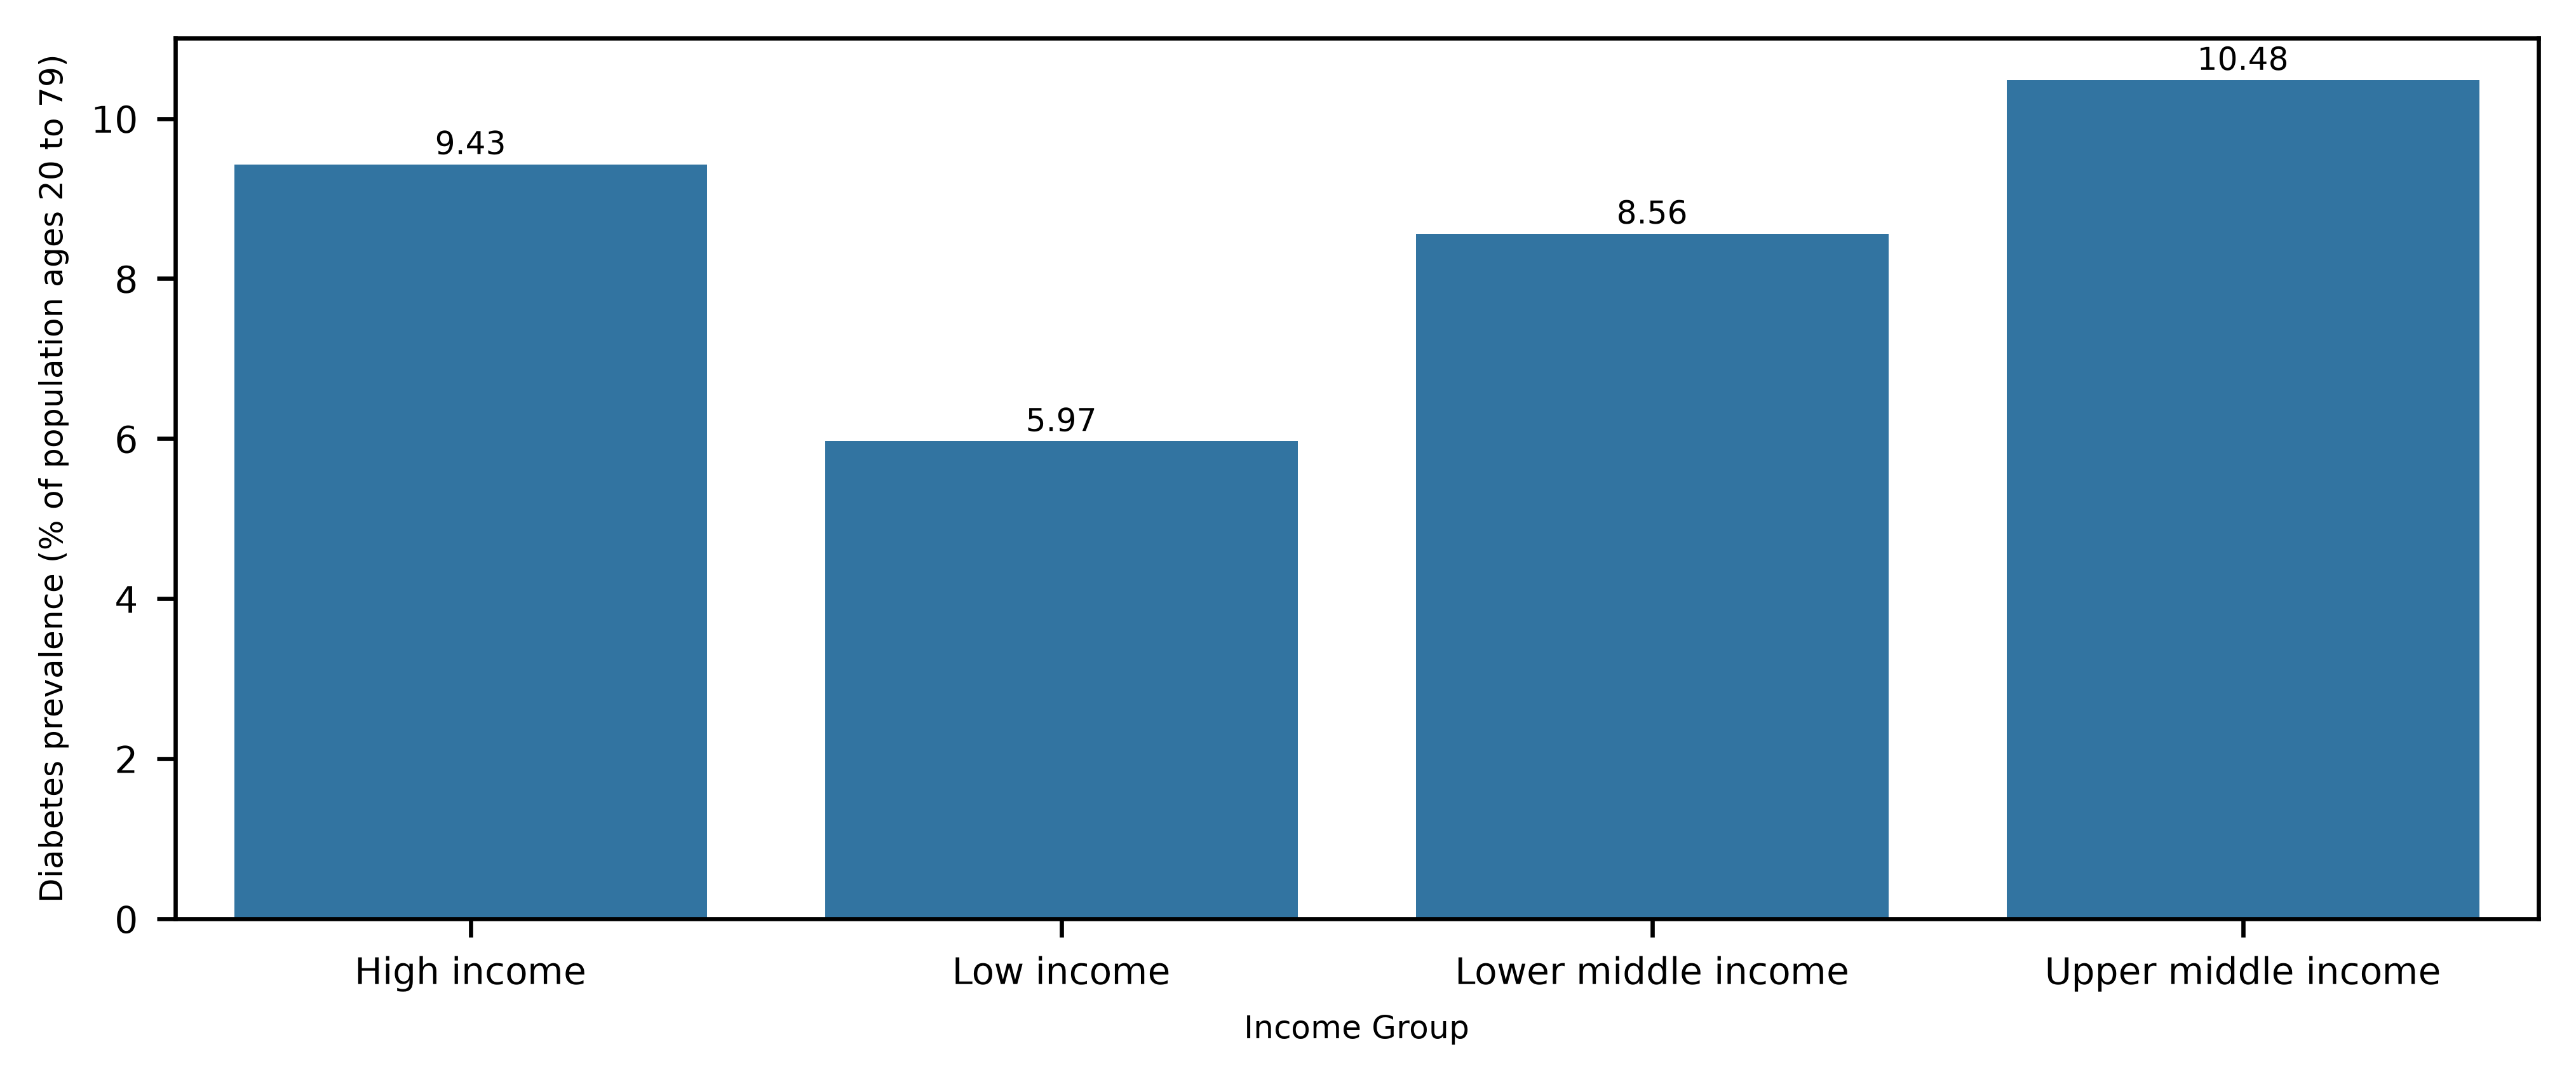

In [28]:
plt.figure(figsize=(8,3), dpi = 600)
ax = sns.barplot(data=diabetes_stats, x=diabetes_stats.iloc[:,0], y=diabetes_stats.iloc[:,1])
for container in ax.containers: 
    ax.bar_label(container, fmt='%.2f', padding=.5, fontsize=6)
plt.xlabel('Income Group',fontsize=6)
plt.ylabel('Diabetes prevalence (% of population ages 20 to 79)', fontsize=6)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()